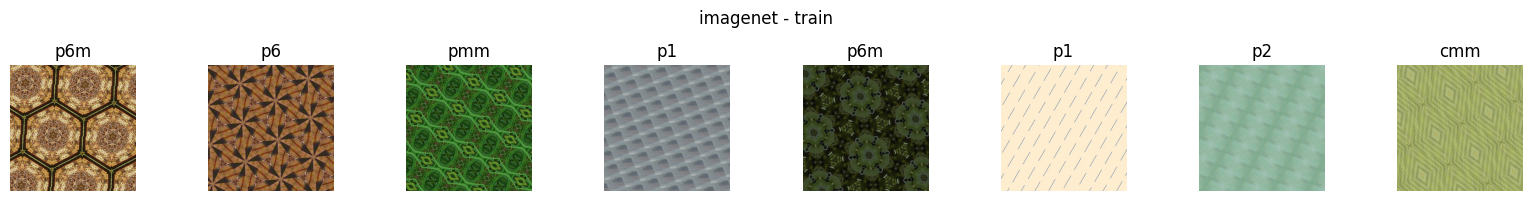

In [1]:
%load_ext autoreload
%autoreload 2
from tqdm import tqdm
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import h5py

import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')
from build_model import resnet50_
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset

# Method to process data in batches and save to a new HDF5 file
def process_and_save_embeddings(model, dataloder, output_h5_path, device, style='single_record'):
    
    '''
    Process the data in batches and save the embeddings to a new HDF5 file
    
    Args:
    - model: PyTorch model
    - dataloder: PyTorch DataLoader object
    - output_h5_path: str, path to save the output HDF5 file
    - style: str, 'single_record' or 'total'
    
    '''
    
    # Open the output HDF5 file for saving embeddings
    with h5py.File(output_h5_path, 'w') as output_h5:
        
        # Create an empty dataset to store the embeddings
        batch_size = dataloder.batch_size
        first_batch = True
        for batch_idx, batch in enumerate(tqdm(dataloder)):
            images, _ = batch
            images = images.to(device)
            
            # Forward pass through the model
            with torch.no_grad():
                embeddings = model(images)
            
            if style == 'total':
                # For the first batch, we can create the HDF5 dataset dynamically based on the shape of embeddings
                if first_batch:
                    embedding_shape = embeddings.shape[1:]  # shape without batch dimension
                    total_samples = len(dataloder.dataset)
                    output_h5.create_dataset('embeddings', shape=(total_samples, *embedding_shape), dtype='float32')
                    first_batch = False

                # Save the current batch embeddings to HDF5
                output_h5['embeddings'][batch_idx * batch_size: (batch_idx + 1) * batch_size] = embeddings.cpu().numpy()
        
            elif style == 'single_record':
                for i in range(embeddings.shape[0]):
                    output_h5.create_dataset(f'embeddings_{batch_idx * batch_size + i}', data=embeddings[i].cpu().numpy()) 
            else:
                raise ValueError(f"Unknown style: {style}")
        
        print(f"Saved embeddings to {output_h5_path}")

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
bs = 8
n_cpus = 1

# imagenet
# imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(imagenet_ds, batch_size=bs, shuffle=True, num_workers=n_cpus)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

In [2]:
device = torch.device('cuda:1')
model = resnet50_(in_channels=3, n_classes=len(symmetry_classes))
model = torch.load('../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt', map_location=device)

# model.fc = nn.Identity()
model.eval()

images, labels = next(iter(train_dl))
print(images.shape, labels.shape)
features = model(images.to(device))
print(features.shape)

torch.Size([8, 3, 256, 256]) torch.Size([8])


RuntimeError: CUDA error: CUBLAS_STATUS_ALLOC_FAILED when calling `cublasCreate(handle)`

In [ ]:
output_h5_path='../../datasets/resnet50-imagenet_v5-embeddings/10092024-resnet50-imagenet_v5_10m-embeddings.h5'
process_and_save_embeddings(model, train_dl, output_h5_path=output_h5_path, device=device, style='single_record')

In [5]:
output_h5_path='../../datasets/resnet50-imagenet_v5-embeddings/10092024-resnet50-imagenet_v5_10m-embeddings.h5'
process_and_save_embeddings(model, train_dl, output_h5_path=output_h5_path, device=device, style='single_record')

100%|██████████| 1563/1563 [02:05<00:00, 12.45it/s]


Saved embeddings to ../../datasets/resnet50-imagenet_v5-embeddings/09292024-resnet50-imagenet_v5_10m-embeddings.h5


In [12]:
output_h5_path='../../datasets/resnet50-imagenet_v5-embeddings/09292024-resnet50-imagenet_v5_10m-probability.h5'
process_and_save_embeddings(model, train_dl, output_h5_path=output_h5_path, device=device, style='single_record')

  0%|          | 219/167345 [00:20<4:18:28, 10.78it/s]


KeyboardInterrupt: 

In [ ]:
output_h5_path='../../datasets/resnet50-imagenet_v5-embeddings/09292024-resnet50-imagenet_v5_10m-probability.h5'
process_and_save_embeddings(model, train_dl, output_h5_path=output_h5_path, device=device, style='single_record')

In [7]:
%load_ext autoreload
%autoreload 2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused, show_cm

device = torch.device('cuda:0')
model = torch.load('../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt', map_location=device).module

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import torch
import os
import h5py
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np

# load the trained resnet50 model
# need to set up
current_dir = r""

model_file = r"../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt"
model_path = os.path.join(current_dir, model_file)

# h5_file = "root.h5"
# h5_path = os.path.join(current_dir, h5_file)

image_folder = "datafed_70k_org"
# image_folder = "datafed_10k_org"
image_dir = os.path.join(current_dir, image_folder)

image_dir
def is_png_file(file_path):
    # Read the first few bytes of the file
    with open(file_path, 'rb') as f:
        header = f.read(8)  # Read the first 8 bytes

    # Check if the file starts with the PNG signature
    return header.startswith(b'\x89PNG\r\n\x1a\n')


# List all image files in the directory
image_files = [f for f in os.listdir(image_dir) if
               f.lower().endswith('.png') and is_png_file(os.path.join(image_dir, f))]

# load the trained resnet50 model
model = models.resnet50()
model.fc = nn.Sequential(nn.BatchNorm1d(2048),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features=2048, out_features=512, bias=False),
                         nn.ReLU(inplace=True),
                         nn.BatchNorm1d(512),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features=512, out_features=64, bias=False),
                         nn.ReLU(inplace=True),
                         nn.BatchNorm1d(64),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features=64, out_features=17, bias=True)
                         )
model = torch.load(model_path,
                   map_location=torch.device('cpu'))
model.eval()


# Function to preprocess batch of images
def preprocess_batch(images):
    preprocessed_images = [plt.imread(img_path)[:, :, :3] for img_path in images]
    preprocessed_images = torch.tensor(np.array(preprocessed_images))
    preprocessed_images = torch.permute(preprocessed_images, (0, 3, 1, 2))
    return preprocessed_images


h5_file_path = image_folder + "_embedding.h5"
# Batch size
batch_size = 20

# Dictionary to store embeddings
embeddings = {}

# Open or create the HDF5 file
if os.path.exists(h5_file_path):
    hf = h5py.File(h5_file_path, 'r+')
else:
    hf = h5py.File(h5_file_path, 'w')

# Embedding and storing each image batch
for i in range(0, len(image_files), batch_size):
    batch_files = image_files[i:i + batch_size]

    # Filter out already embedded images
    batch_files_to_embed = [img_file for img_file in batch_files if img_file not in hf]

    if not batch_files_to_embed:
        continue  # If all images in the batch are already embedded, skip this batch

    batch_images = [os.path.join(image_dir, img_file) for img_file in batch_files_to_embed]
    batch_images = preprocess_batch(batch_images)

    # Assuming model returns a tensor of embeddings
    batch_embeddings = model(batch_images.to('cpu'))

    # Store the embeddings in the HDF5 file
    for j, img_file in enumerate(batch_files_to_embed):
        hf.create_dataset(img_file, data=batch_embeddings[j].detach().numpy())

    # Calculate percentage completion
    percentage_done = (i + batch_size) / len(image_files) * 100
    print(f"Percentage done: {percentage_done:.2f}%")

# Close the HDF5 file after processing
hf.close()

'datafed_70k_org'

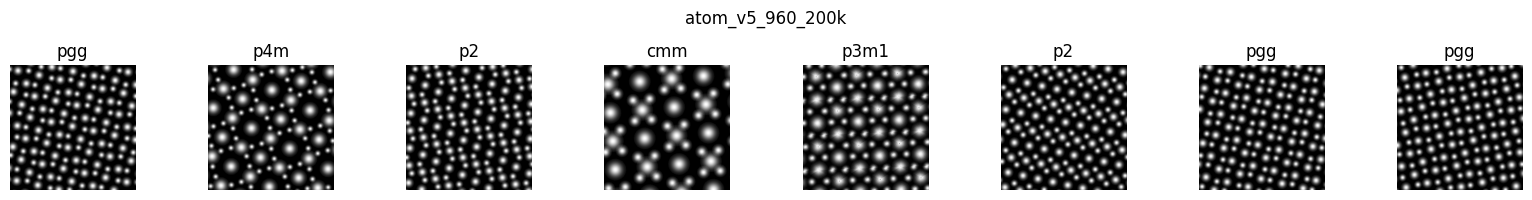

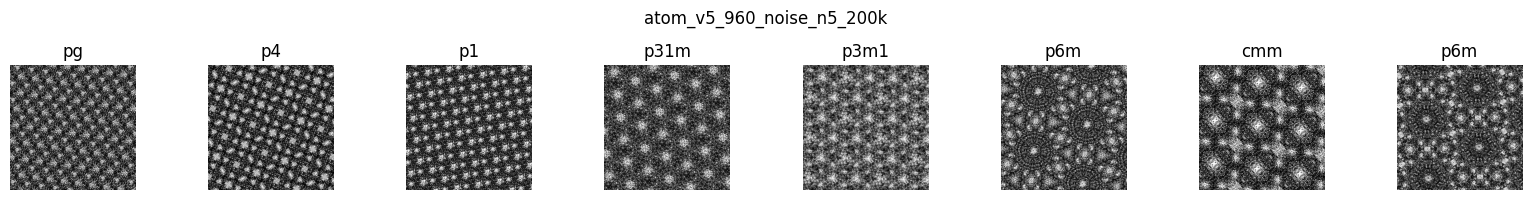

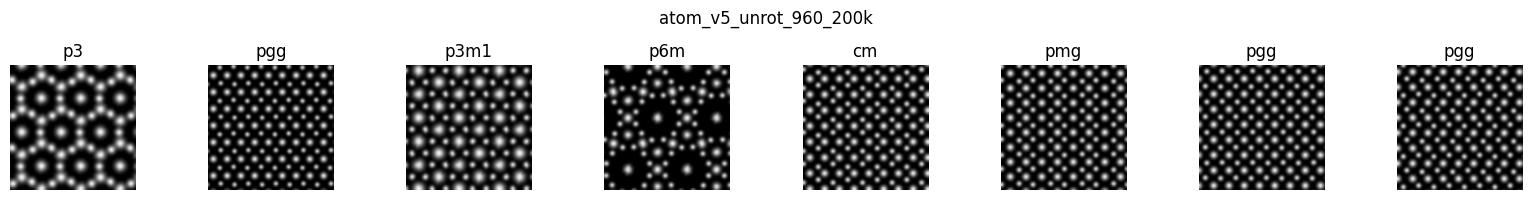

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# atom_v5_960_200k
atom_v5_200k_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_200k_dl = DataLoader(atom_v5_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_200k_dl, label_converter=label_converter, title='atom_v5_960_200k')

# atom_v5_noise_n5_200k
atom_v5_noise_n5_200k_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_noise_n5_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_noise_n5_200k_dl = DataLoader(atom_v5_noise_n5_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_noise_n5_200k_dl, label_converter=label_converter, title='atom_v5_960_noise_n5_200k')

# atom_v5_unrot_960_200k
atom_v5_unrot_960_200k_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_unrot_960_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_unrot_960_200k_dl = DataLoader(atom_v5_unrot_960_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_unrot_960_200k_dl, label_converter=label_converter, title='atom_v5_unrot_960_200k')
plt.show()